### Testing script of the CNN model
#### TODO:

+ Check how to improve the adaptive one so we can get similar scores
+ Make sure to save the other options still!!
+ Data Augmentation options!!

**At the end**
+ Make it all in a script to be run from command line
+ Add argument parsing for hyperparameters


### **Notes to the output and the version meanings**
#### /cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
+ _wo_normalization: There we did not normalize the img in Load_Cifar with std and dev
+ v1: without data augmentation

Simple CNN
Total Training Time  : 338.53s
Total Validation Time: 43.40s

SimpleAdaptiveCNN
Total Training Time  : 338.12s
Total Validation Time: 42.64s


+ v2: with data augmentation

Simple CNN
Total Training Time  : 417.16s
Total Validation Time: 50.60s

SimpleAdaptiveCNN
Total Training Time  : 454.24s
Total Validation Time: 51.46s


#### /cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
+ no suffix: without data augmentation

Simple CNN
Total Training Time  : 663.27s
Total Validation Time: 78.77s

SimpleAdaptiveCNN
Total Training Time  : 626.09s
Total Validation Time: 77.79s


+ v1: with data augmentation

Simple CNN
Total Training Time  : 615.57s
Total Validation Time: 71.32s

SimpleAdaptiveCNN
Total Training Time  : 747.35s
Total Validation Time: 83.39s


#### /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
+ no suffix: without data augmentation

Simple CNN
Total Training Time  : 711.45s
Total Validation Time: 85.77s

SimpleAdaptiveCNN
Total Training Time  : 638.99s
Total Validation Time: 75.98s


+ v1: with data augmentation

Simple CNN
Total Training Time  : 714.55s
Total Validation Time: 82.98s

SimpleAdaptiveCNN
Total Training Time  : 856.05s
Total Validation Time: 99.30s

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

# Local imports
from cnn import SimpleCNN, SimpleAdaptiveCNN
from data.load_cifar import CIFAR10
from train import train_model
from analysis.evaluation import evaluate_model

# https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903
# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision.transforms as transforms
from torchvision.transforms import v2


# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomCrop(32, padding=4),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
])
#train_transforms = None
val_transforms = None

# Create datasets
train_dataset = CIFAR10(split="train", transform=train_transforms)
test_dataset  = CIFAR10(split="test", transform=val_transforms)

# Class names in CIFAR-10
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Using device: cpu


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/Exercise3/data/load_cifar.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding="bytes")
/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train samples: 50000
Test samples: 10000
Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


Training model: SimpleCNN
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Train Loss: 1.7179 | Train Acc: 0.3699
Train Time: 34.94s
Val   Loss: 1.3192 | Val   Acc: 0.5193
Val   Time: 3.83s

Epoch 2/10


Train Loss: 1.3790 | Train Acc: 0.5034
Train Time: 35.80s
Val   Loss: 1.0986 | Val   Acc: 0.6084
Val   Time: 3.95s

Epoch 3/10


Train Loss: 1.2038 | Train Acc: 0.5716
Train Time: 39.70s
Val   Loss: 0.9623 | Val   Acc: 0.6695
Val   Time: 4.87s

Epoch 4/10


...

Train Loss: 0.9607 | Train Acc: 0.6665
Train Time: 42.43s
Val   Loss: 0.8187 | Val   Acc: 0.7125
Val   Time: 4.89s

Epoch 7/10


Train Loss: 0.9093 | Train Acc: 0.6834
Train Time: 43.48s
Val   Loss: 0.7935 | Val   Acc: 0.7191
Val   Time: 5.36s

Epoch 8/10


Train Loss: 0.8680 | Train Acc: 0.6992
Train Time: 46.29s
Val   Loss: 0.7271 | Val   Acc: 0.7532
Val   Time: 5.19s

Epoch 9/10


Train Loss: 0.8340 | Train Acc: 0.7117
Train Time: 42.82s
Val   Loss: 0.7250 | Val   Acc: 0.7541
Val   Time: 7.94s

Epoch 10/10


Train Loss: 0.8164 | Train Acc: 0.7167
Train Time: 54.89s
Val   Loss: 0.6988 | Val   Acc: 0.7547
Val   Time: 5.04s

Total Training Time  : 417.16s
Total Validation Time: 50.60s


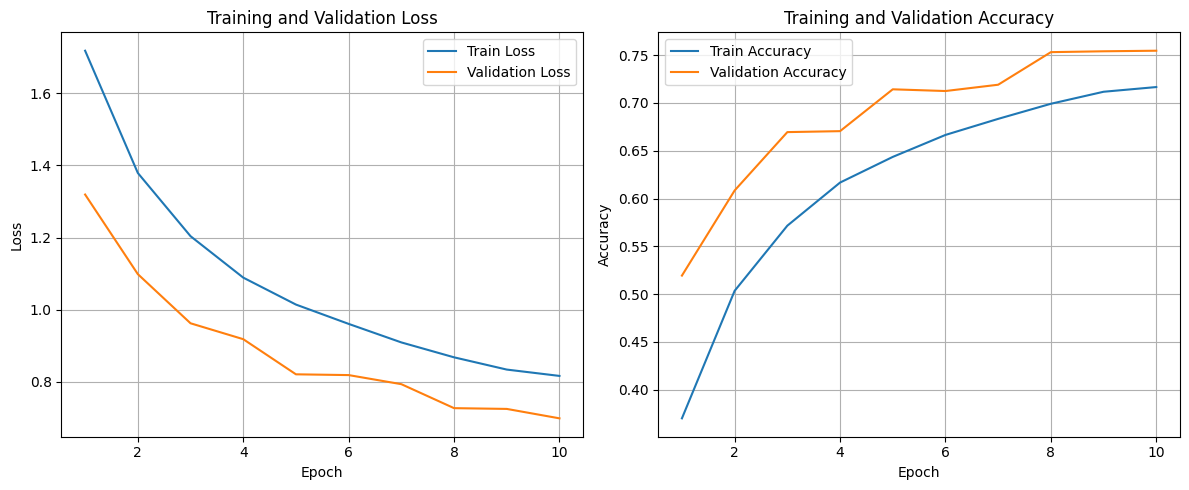

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_cifar10_v2.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.7547

Model Evaluation
----------------
Overall accuracy: 0.7547

Per-class accuracy:
  airplane: 0.818
automobile: 0.916
      bird: 0.625
       cat: 0.548
      deer: 0.672
       dog: 0.753
      frog: 0.836
     horse: 0.736
      ship: 0.780
     truck: 0.863

Classification report:
              precision    recall  f1-score   support

    airplane      0.762     0.818     0.789      1000
  automobile      0.859     0.916     0.887      1000
        bird      0.659     0.625     0.641      1000
         cat      0.583     0.548     0.565      1000
        deer      0.787     0.672     0.725      1000
         dog      0.586     0.753     0.659      1000
        frog      0.774     0.836     0.804      1000
       horse      0.859     0.736     0.793      1000
        ship      0.935     0.780     0.851      1000
      

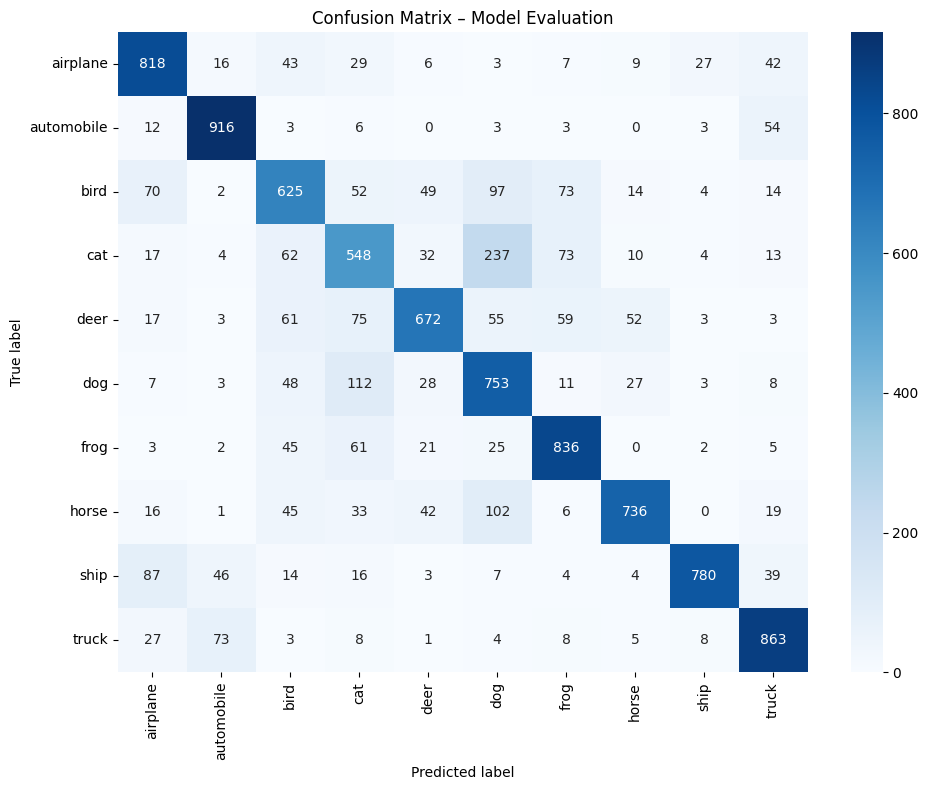

Training model: SimpleAdaptiveCNN
SimpleAdaptiveCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.8872 | Train Acc: 0.2795
Train Time: 44.82s
Val   Loss: 1.5650 | Val   Acc: 0.4155
Val   Time: 5.05s

Epoch 2/10


Train Loss: 1.5790 | Train Acc: 0.4122
Train Time: 42.99s
Val   Loss: 1.4468 | Val   Acc: 0.4722
Val   Time: 4.86s

Epoch 3/10


Train Loss: 1.4005 | Train Acc: 0.4859
Train Time: 42.27s
Val   Loss: 1.2981 | Val   Acc: 0.5240
Val   Time: 4.55s

Epoch 4/10


...

Train Loss: 1.1468 | Train Acc: 0.5889
Train Time: 44.81s
Val   Loss: 1.0867 | Val   Acc: 0.6066
Val   Time: 5.02s

Epoch 7/10


Train Loss: 1.0826 | Train Acc: 0.6142
Train Time: 46.35s
Val   Loss: 1.0435 | Val   Acc: 0.6253
Val   Time: 5.23s

Epoch 8/10


Train Loss: 1.0324 | Train Acc: 0.6307
Train Time: 50.66s
Val   Loss: 0.9920 | Val   Acc: 0.6444
Val   Time: 5.80s

Epoch 9/10


Train Loss: 0.9953 | Train Acc: 0.6487
Train Time: 50.59s
Val   Loss: 0.9228 | Val   Acc: 0.6704
Val   Time: 6.06s

Epoch 10/10


Train Loss: 0.9611 | Train Acc: 0.6597
Train Time: 48.60s
Val   Loss: 0.9380 | Val   Acc: 0.6592
Val   Time: 5.61s

Total Training Time  : 454.24s
Total Validation Time: 51.46s


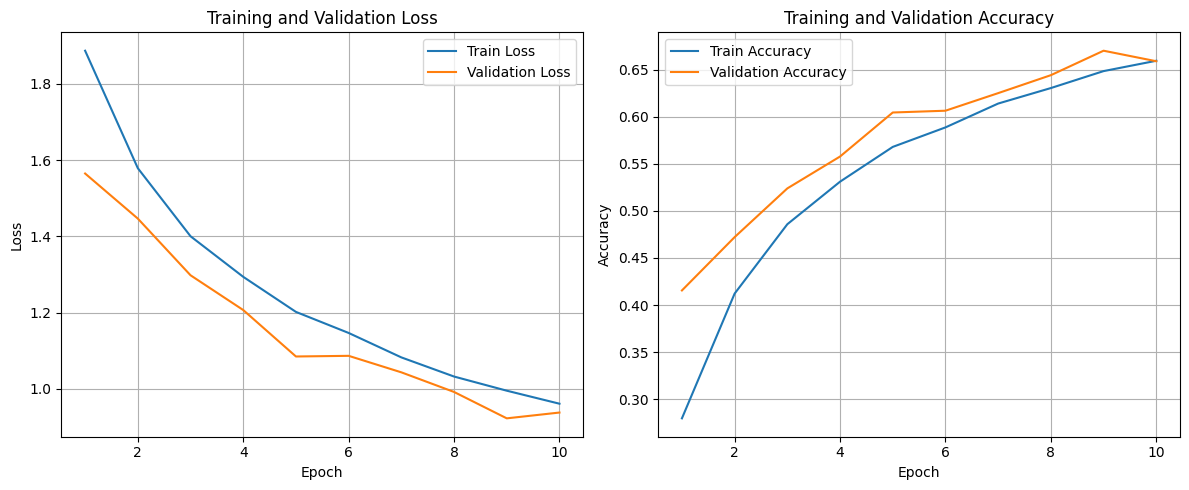

Training completed.
Saved trained model to: cnn_trained_models/simpleadaptivecnn_cifar10_v2.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.6592

Model Evaluation
----------------
Overall accuracy: 0.6592

Per-class accuracy:
  airplane: 0.638
automobile: 0.692
      bird: 0.313
       cat: 0.446
      deer: 0.569
       dog: 0.705
      frog: 0.751
     horse: 0.762
      ship: 0.852
     truck: 0.864

Classification report:
              precision    recall  f1-score   support

    airplane      0.783     0.638     0.703      1000
  automobile      0.920     0.692     0.790      1000
        bird      0.694     0.313     0.431      1000
         cat      0.424     0.446     0.435      1000
        deer      0.637     0.569     0.601      1000
         dog      0.474     0.705     0.567      1000
        frog      0.668     0.751     0.707      1000
       horse      0.689     0.762     0.724      1000
        ship      0.765     0.852     0.806      100

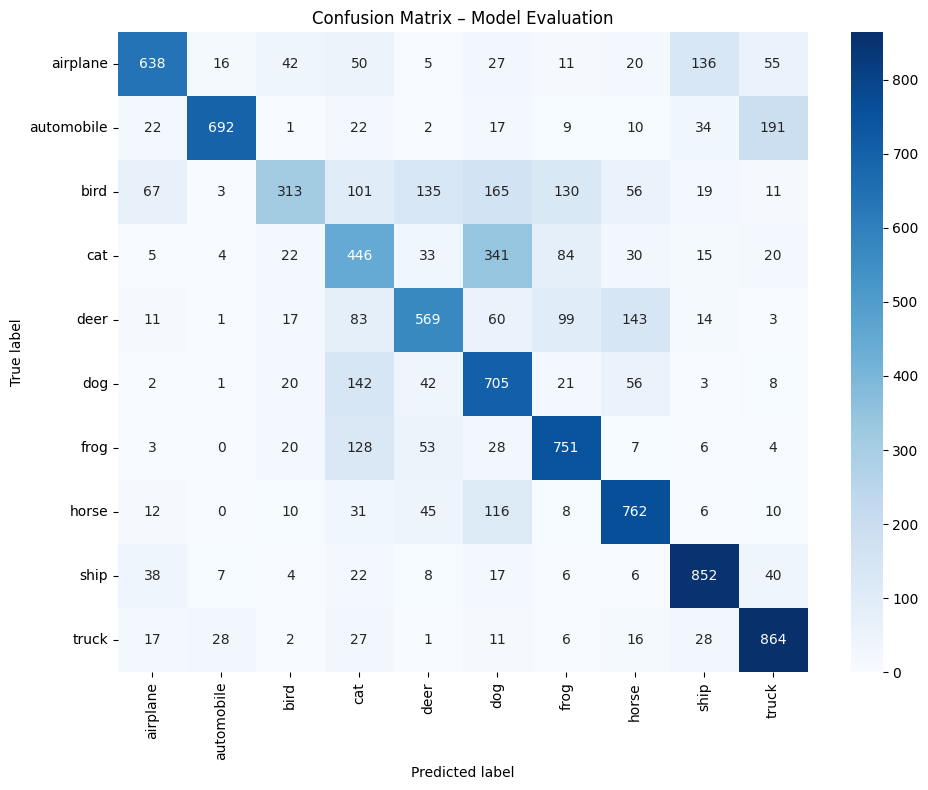

In [19]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2
epochs=10

model_selection = {"SimpleCNN": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier), 
                    "SimpleAdaptiveCNN": SimpleAdaptiveCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier)
                                }

for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss() # loss function cross entropy that will be used for calculating the loss during training so that the optimizer can update the weights accordingly (remember backpropagation!)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_cifar10.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)

    del trained_model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Class names from the dataset
classes = train_dataset.classes

def unnormalize(img_tensor):
    # Convert normalized tensor back to image for display
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def show_augmented_vs_original(transform, dataset, num_images=8):
    # Get original images (PIL) from dataset
    original_images = [dataset[i][0] for i in range(num_images)]

    # Apply augmentations
    augmented_images = [transform(img) for img in original_images]

    fig, axs = plt.subplots(2, num_images, figsize=(16, 4))
    fig.suptitle('Original Images (Top) vs. Augmented Images (Bottom)', fontsize=16)

    for i in range(num_images):
        # Display original images
        axs[0, i].imshow(original_images[i])
        axs[0, i].axis('off')
        if i == 0:
            axs[0, i].set_ylabel('Original', fontsize=12)

        # Display augmented images (unnormalized tensor)
        img = unnormalize(augmented_images[i])
        axs[1, i].imshow(img)
        axs[1, i].axis('off')
        if i == 0:
            axs[1, i].set_ylabel('Augmented', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# To use this function, pass your transform pipeline and the raw dataset without transforms:
show_augmented_vs_original(transform=train_transforms, dataset=raw_dataset)

### Old testing area


In [ ]:
trained_model = train_model(
    model=model,
    trainloader=trainloader,
    valloader=valloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=10
)


Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Training: 100%|██████████| 391/391 [00:33<00:00, 12.43it/s]

In [ ]:
# save the trained model
file_name = "cnn_trained_models/simple_cnn_cifar10_v2.pth"
torch.save(trained_model.state_dict(), file_name)
#del trained_model

In [8]:
# load the saved model with the same parameters initially set
trained_model = SimpleCNN(in_channels=3, num_classes=10, input_size=32, base_channels=32, channel_multiplier=2)
trained_model.load_state_dict(torch.load(file_name))

<All keys matched successfully>

In [9]:
trained_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in valloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

print(f"Final validation accuracy: {correct / total:.4f}")


Final validation accuracy: 0.7299


In [10]:
from analysis.evaluation import evaluate_model

/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Model Evaluation
----------------
Overall accuracy: 0.7299

Per-class accuracy:
  airplane: 0.861
automobile: 0.890
      bird: 0.627
       cat: 0.534
      deer: 0.649
       dog: 0.521
      frog: 0.822
     horse: 0.799
      ship: 0.852
     truck: 0.744

Classification report:
              precision    recall  f1-score   support

    airplane      0.643     0.861     0.736      1000
  automobile      0.807     0.890     0.846      1000
        bird      0.637     0.627     0.632      1000
         cat      0.554     0.534     0.544      1000
        deer      0.720     0.649     0.682      1000
         dog      0.719     0.521     0.604      1000
        frog      0.800     0.822     0.811      1000
       horse      0.757     0.799     0.778      1000
        ship      0.824     0.852     0.838      1000
       truck      0.859     0.744     0.797      1000

    accuracy                          0.730     10000
   macro avg      0.732     0.730     0.727     10000
weighted av

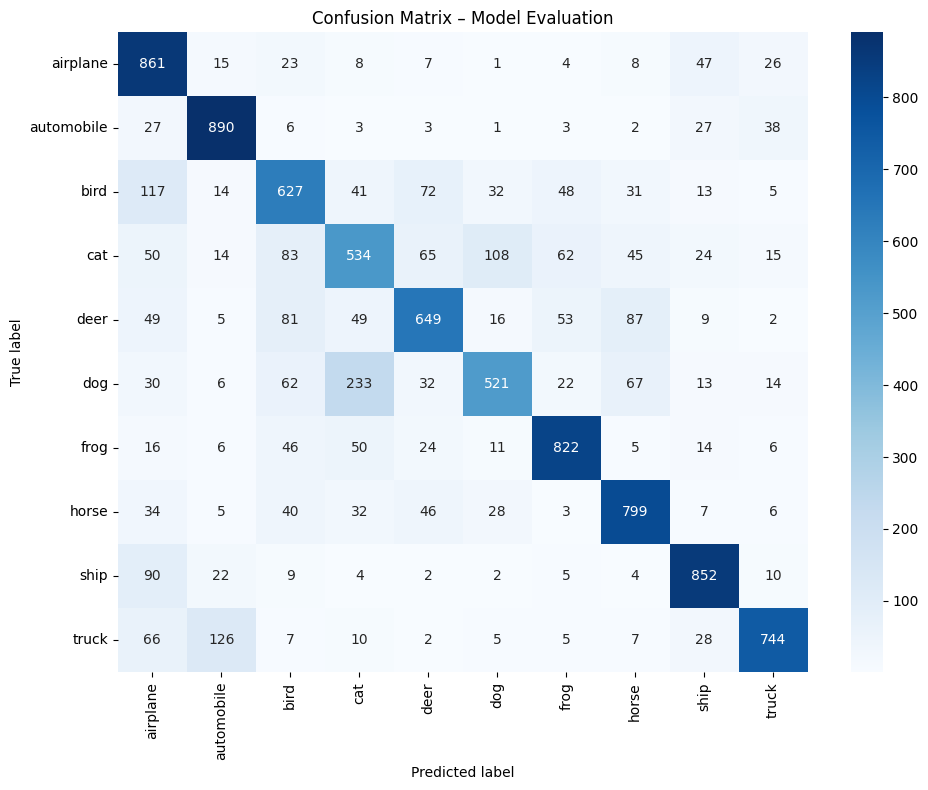

{'overall_accuracy': 0.7299000024795532,
 'per_class_accuracy': array([0.861, 0.89 , 0.627, 0.534, 0.649, 0.521, 0.822, 0.799, 0.852,
        0.744]),
 'confusion_matrix': array([[861,  15,  23,   8,   7,   1,   4,   8,  47,  26],
        [ 27, 890,   6,   3,   3,   1,   3,   2,  27,  38],
        [117,  14, 627,  41,  72,  32,  48,  31,  13,   5],
        [ 50,  14,  83, 534,  65, 108,  62,  45,  24,  15],
        [ 49,   5,  81,  49, 649,  16,  53,  87,   9,   2],
        [ 30,   6,  62, 233,  32, 521,  22,  67,  13,  14],
        [ 16,   6,  46,  50,  24,  11, 822,   5,  14,   6],
        [ 34,   5,  40,  32,  46,  28,   3, 799,   7,   6],
        [ 90,  22,   9,   4,   2,   2,   5,   4, 852,  10],
        [ 66, 126,   7,  10,   2,   5,   5,   7,  28, 744]]),
 'predictions': tensor([3, 8, 8,  ..., 5, 4, 7]),
 'labels': tensor([3, 8, 8,  ..., 5, 1, 7])}

In [11]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]
evaluate_model(trained_model, valloader, device="cpu", class_names=class_names)

In [21]:
# target output size of 5x7
m = nn.AdaptiveAvgPool2d((5, 7))
input = torch.randn(1, 64, 8, 9)
output = m(input)
print(output.shape)

# target output size of 7x7 (square)
m = nn.AdaptiveAvgPool2d(7)
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of 10x7
m = nn.AdaptiveAvgPool2d((None, 7))
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of 15x15
m = nn.AdaptiveAvgPool2d((15, 15))
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of the same size
m = nn.AdaptiveAvgPool2d((2,2))
input = torch.randn(1, 6, 2, 2)
output = m(input)
print(output.shape)


torch.Size([1, 64, 5, 7])
torch.Size([1, 64, 7, 7])
torch.Size([1, 64, 10, 7])
torch.Size([1, 64, 15, 15])
torch.Size([1, 6, 2, 2])


In [23]:
input , output

(tensor([[[[-0.9263, -0.5816],
           [-1.1925, -0.3591]],
 
          [[ 0.8660, -0.3756],
           [-2.2855,  1.0001]],
 
          [[-1.5795, -0.2661],
           [-0.6010, -1.2038]],
 
          [[ 1.5281,  1.4366],
           [ 1.2875, -1.0313]],
 
          [[-1.2212, -0.4418],
           [-0.2393,  0.5293]],
 
          [[ 0.0678, -0.5407],
           [ 1.0346,  0.4056]]]]),
 tensor([[[[-0.9263, -0.5816],
           [-1.1925, -0.3591]],
 
          [[ 0.8660, -0.3756],
           [-2.2855,  1.0001]],
 
          [[-1.5795, -0.2661],
           [-0.6010, -1.2038]],
 
          [[ 1.5281,  1.4366],
           [ 1.2875, -1.0313]],
 
          [[-1.2212, -0.4418],
           [-0.2393,  0.5293]],
 
          [[ 0.0678, -0.5407],
           [ 1.0346,  0.4056]]]]))